In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import re
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')

# Estilo visual
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid', palette='muted')

print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')

Pandas  : 2.3.3
NumPy   : 2.2.6


In [14]:
BASE_PATH = '                    CAMBIA LA RUTA DE TU ARCHIVO       '

# Archivos disponibles
archivos = os.listdir(BASE_PATH)
print('Archivos en el directorio:')
for f in sorted(archivos):
    size_mb = os.path.getsize(os.path.join(BASE_PATH, f)) / 1e6
    print(f'  {f:40s} {size_mb:.1f} MB')

Archivos en el directorio:
  key_1.csv.zip                            100.6 MB
  key_2.csv.zip                            105.7 MB
  sample_submission_1.csv.zip              69.2 MB
  sample_submission_2.csv.zip              71.5 MB
  train_1.csv.zip                          107.4 MB
  train_2.csv.zip                          157.5 MB


In [17]:
train_path = os.path.join(BASE_PATH, 'train_1.csv.zip')
df_raw = pd.read_csv(train_path)

print(f' Dataset cargado')
print(f'   Filas (páginas) : {df_raw.shape[0]:,}')
print(f'   Columnas (1 + fechas): {df_raw.shape[1]:,}')
print(f'   Rango temporal  : {df_raw.columns[1]} → {df_raw.columns[-1]}')
df_raw.head(3)

 Dataset cargado
   Filas (páginas) : 145,063
   Columnas (1 + fechas): 551
   Rango temporal  : 2015-07-01 → 2016-12-31


,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0


In [18]:
def parse_page_name(name):
    """
    Extrae: idioma, tipo de acceso y agente desde el nombre de página.
    Formato esperado: Artículo_xx.wikipedia.org_acceso_agente
    """
    pattern = r'(.+)_([a-z]{2,3}\.wikipedia\.org)_(all-access|desktop|mobile-web|mobile-app)_(all-agents|spider|user)$'
    m = re.match(pattern, name)
    if m:
        return m.group(2).split('.')[0], m.group(3), m.group(4)
    return 'unknown', 'unknown', 'unknown'

# Parsear nombres
parsed = df_raw['Page'].apply(parse_page_name)
df_raw['idioma'] = [p[0] for p in parsed]
df_raw['acceso'] = [p[1] for p in parsed]
df_raw['agente'] = [p[2] for p in parsed]

print('Distribución por idioma:')
print(df_raw['idioma'].value_counts().head(10))
print('\nDistribución por tipo de acceso:')
print(df_raw['acceso'].value_counts())
print('\nDistribución por agente:')
print(df_raw['agente'].value_counts())

Distribución por idioma:
idioma
en         24108
ja         20431
de         18547
unknown    17855
fr         17802
zh         17229
ru         15022
es         14069
Name: count, dtype: int64

Distribución por tipo de acceso:
acceso
all-access    65713
mobile-web    30923
desktop       30572
unknown       17855
Name: count, dtype: int64

Distribución por agente:
agente
all-agents    96594
spider        30614
unknown       17855
Name: count, dtype: int64


Total de días en el dataset: 550
Desde: 2015-07-01  →  Hasta: 2016-12-31


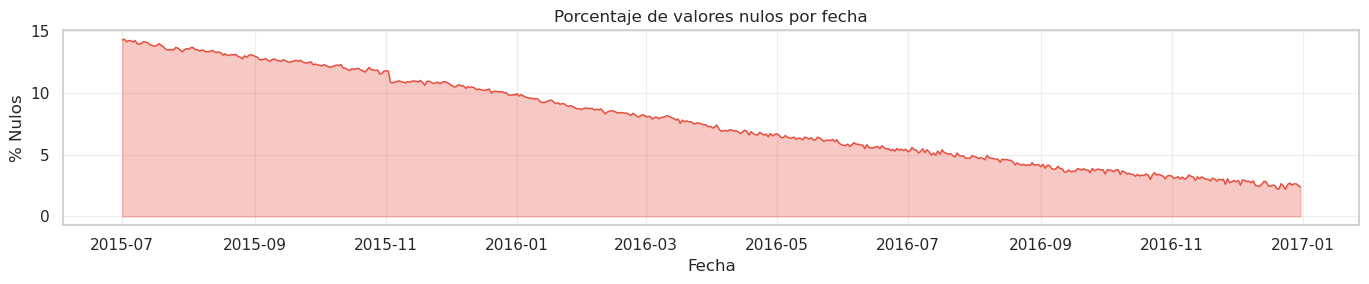


Promedio global de nulos: 7.76%


In [19]:
date_cols = [c for c in df_raw.columns if re.match(r'\d{4}-\d{2}-\d{2}', c)]
print(f'Total de días en el dataset: {len(date_cols)}')
print(f'Desde: {date_cols[0]}  →  Hasta: {date_cols[-1]}')

null_pct = df_raw[date_cols].isnull().mean() * 100

plt.figure(figsize=(14, 3))
plt.plot(pd.to_datetime(date_cols), null_pct.values, color='#e74c3c', linewidth=1)
plt.fill_between(pd.to_datetime(date_cols), null_pct.values, alpha=0.3, color='#e74c3c')
plt.title('Porcentaje de valores nulos por fecha')
plt.ylabel('% Nulos')
plt.xlabel('Fecha')
plt.tight_layout()
plt.show()
print(f'\nPromedio global de nulos: {null_pct.mean():.2f}%')

In [20]:
traffic = df_raw[date_cols].fillna(0)
total_by_day = traffic.sum(axis=0)  # tráfico total por día
total_by_day.index = pd.to_datetime(total_by_day.index)

print('Estadísticas de tráfico total diario (todas las páginas):')
print(total_by_day.describe().apply(lambda x: f'{x:,.0f}'))

Estadísticas de tráfico total diario (todas las páginas):
count            550
mean     189,998,581
std       31,607,708
min      127,190,355
25%      170,599,388
50%      186,021,076
75%      203,114,510
max      316,944,994
dtype: object


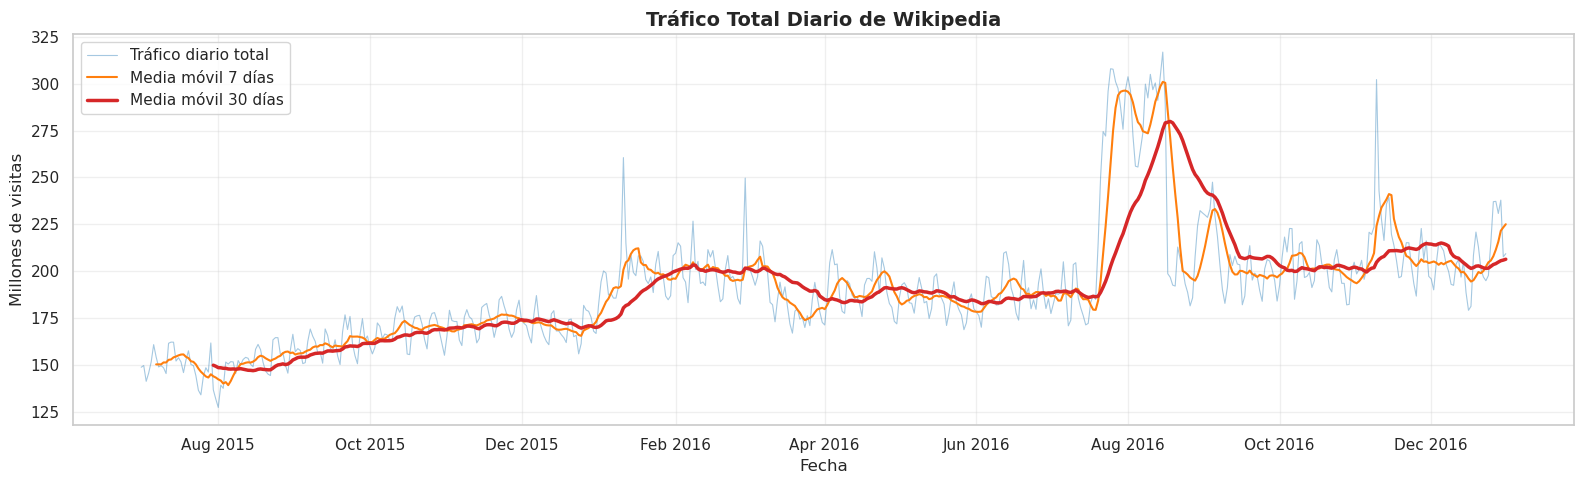

In [21]:
rolmean_30 = total_by_day.rolling(window=30).mean()
rolmean_7  = total_by_day.rolling(window=7).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(total_by_day.index, total_by_day.values / 1e6,
        color='#1f77b4', alpha=0.4, linewidth=0.8, label='Tráfico diario total')
ax.plot(rolmean_7.index, rolmean_7.values / 1e6,
        color='#ff7f0e', linewidth=1.5, label='Media móvil 7 días')
ax.plot(rolmean_30.index, rolmean_30.values / 1e6,
        color='#d62728', linewidth=2.5, label='Media móvil 30 días')

ax.set_title('Tráfico Total Diario de Wikipedia', fontsize=14, fontweight='bold')
ax.set_ylabel('Millones de visitas')
ax.set_xlabel('Fecha')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.legend()
plt.tight_layout()
plt.show()

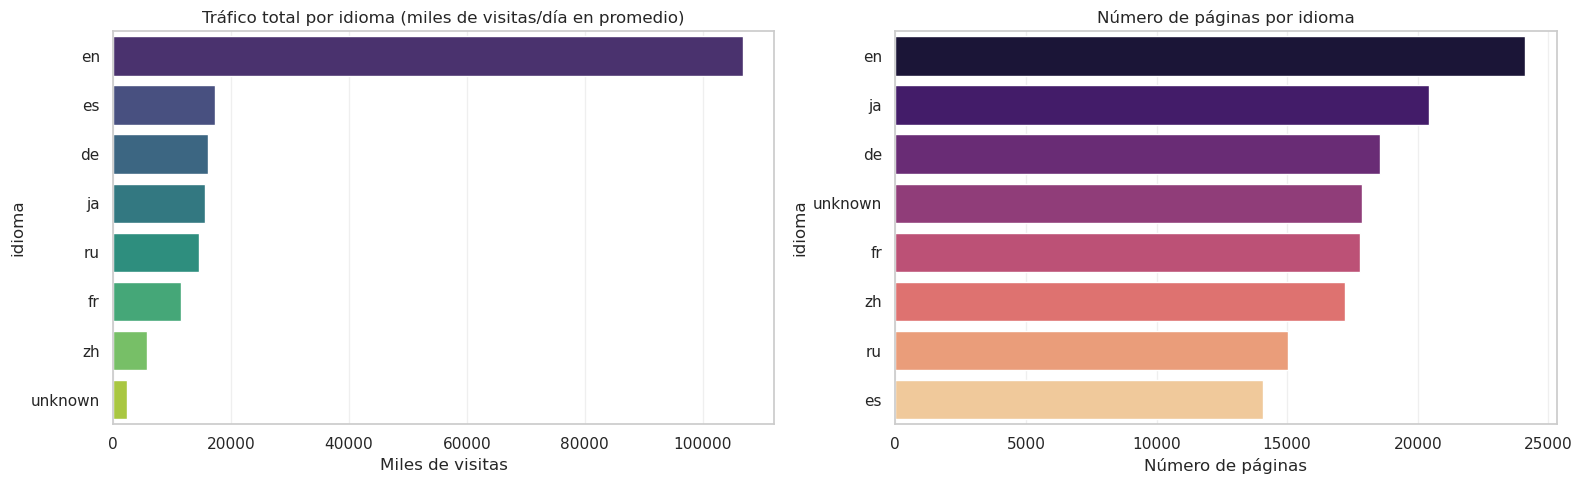

In [22]:
# ── TRÁFICO PROMEDIO POR IDIOMA ─────────────────────────────────────────────
df_raw['trafico_medio'] = traffic.mean(axis=1)
trafico_idioma = df_raw.groupby('idioma')['trafico_medio'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot de tráfico por idioma
top_idiomas = trafico_idioma.head(12)
sns.barplot(x=top_idiomas.values / 1e3, y=top_idiomas.index, ax=axes[0], palette='viridis')
axes[0].set_title('Tráfico total por idioma (miles de visitas/día en promedio)')
axes[0].set_xlabel('Miles de visitas')

# Número de páginas por idioma
paginas_idioma = df_raw['idioma'].value_counts().head(12)
sns.barplot(x=paginas_idioma.values, y=paginas_idioma.index, ax=axes[1], palette='magma')
axes[1].set_title('Número de páginas por idioma')
axes[1].set_xlabel('Número de páginas')

plt.tight_layout()
plt.show()

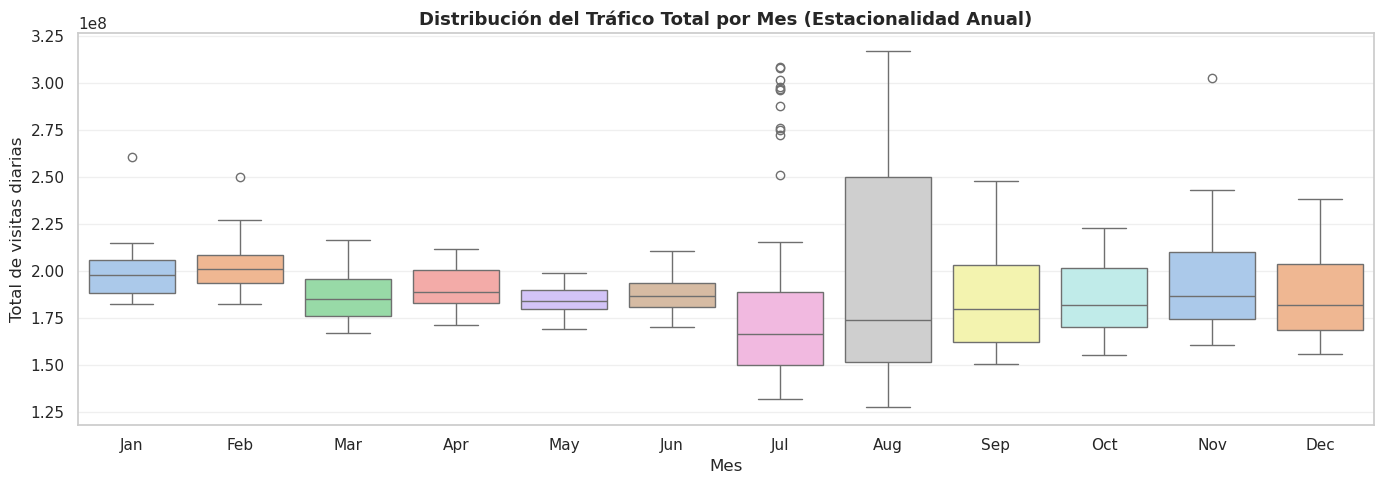

Mediana de visitas diarias por mes:
mes_nombre
Jan    197,396,154
Feb    200,927,608
Mar    184,801,364
Apr    188,358,194
May    183,806,773
Jun    186,326,704
Jul    166,448,088
Aug    173,864,050
Sep    179,344,820
Oct    181,679,102
Nov    186,589,377
Dec    181,463,649
Name: visitas, dtype: object


In [23]:
# ── BOXPLOT DE VARIABILIDAD MENSUAL ────────────────────────────────────────
df_diario = total_by_day.reset_index()
df_diario.columns = ['fecha', 'visitas']
df_diario['mes'] = df_diario['fecha'].dt.month
df_diario['mes_nombre'] = df_diario['fecha'].dt.strftime('%b')
df_diario['año'] = df_diario['fecha'].dt.year

meses_orden = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df_diario['mes_nombre'] = pd.Categorical(df_diario['mes_nombre'], categories=meses_orden, ordered=True)

plt.figure(figsize=(14, 5))
sns.boxplot(
    data=df_diario,
    x='mes_nombre',
    y='visitas',
    palette='pastel',
    order=meses_orden
)
plt.title('Distribución del Tráfico Total por Mes (Estacionalidad Anual)', fontsize=13, fontweight='bold')
plt.ylabel('Total de visitas diarias')
plt.xlabel('Mes')
plt.tight_layout()
plt.show()

print('Mediana de visitas diarias por mes:')
print(df_diario.groupby('mes_nombre', observed=True)['visitas'].median().apply(lambda x: f'{x:,.0f}'))

In [24]:
df_raw['trafico_total'] = traffic.sum(axis=1)
df_sorted = df_raw.sort_values('trafico_total', ascending=False)

# Top 5 y bottom 5
top5 = df_sorted.head(5)
print('🔝 Top 5 páginas con más tráfico:')
for _, row in top5.iterrows():
    print(f'  {row["Page"][:70]:<70}  {row["trafico_total"]:>15,.0f} visitas totales')

print('\n🔻 Top 5 páginas con menos tráfico:')
bottom5 = df_sorted.tail(5)
for _, row in bottom5.iterrows():
    print(f'  {row["Page"][:70]:<70}  {row["trafico_total"]:>15,.0f} visitas totales')

🔝 Top 5 páginas con más tráfico:
  Main_Page_en.wikipedia.org_all-access_all-agents                         12,066,181,102 visitas totales
  Main_Page_en.wikipedia.org_desktop_all-agents                             8,774,497,458 visitas totales
  Main_Page_en.wikipedia.org_mobile-web_all-agents                          3,153,984,882 visitas totales
  Wikipedia:Hauptseite_de.wikipedia.org_all-access_all-agents               1,603,934,248 visitas totales
  Special:Search_en.wikipedia.org_all-access_all-agents                     1,304,079,353 visitas totales

🔻 Top 5 páginas con menos tráfico:
  Изнасилование_Дианы_Шурыгиной_ru.wikipedia.org_all-access_all-agents                  0 visitas totales
  Ждун_ru.wikipedia.org_all-access_all-agents                                           0 visitas totales
  Адаптация_(телесериал)_ru.wikipedia.org_all-access_all-agents                         0 visitas totales
  Петров,_Владимир_Владимирович_(хоккеист)_ru.wikipedia.org_all-access_a           

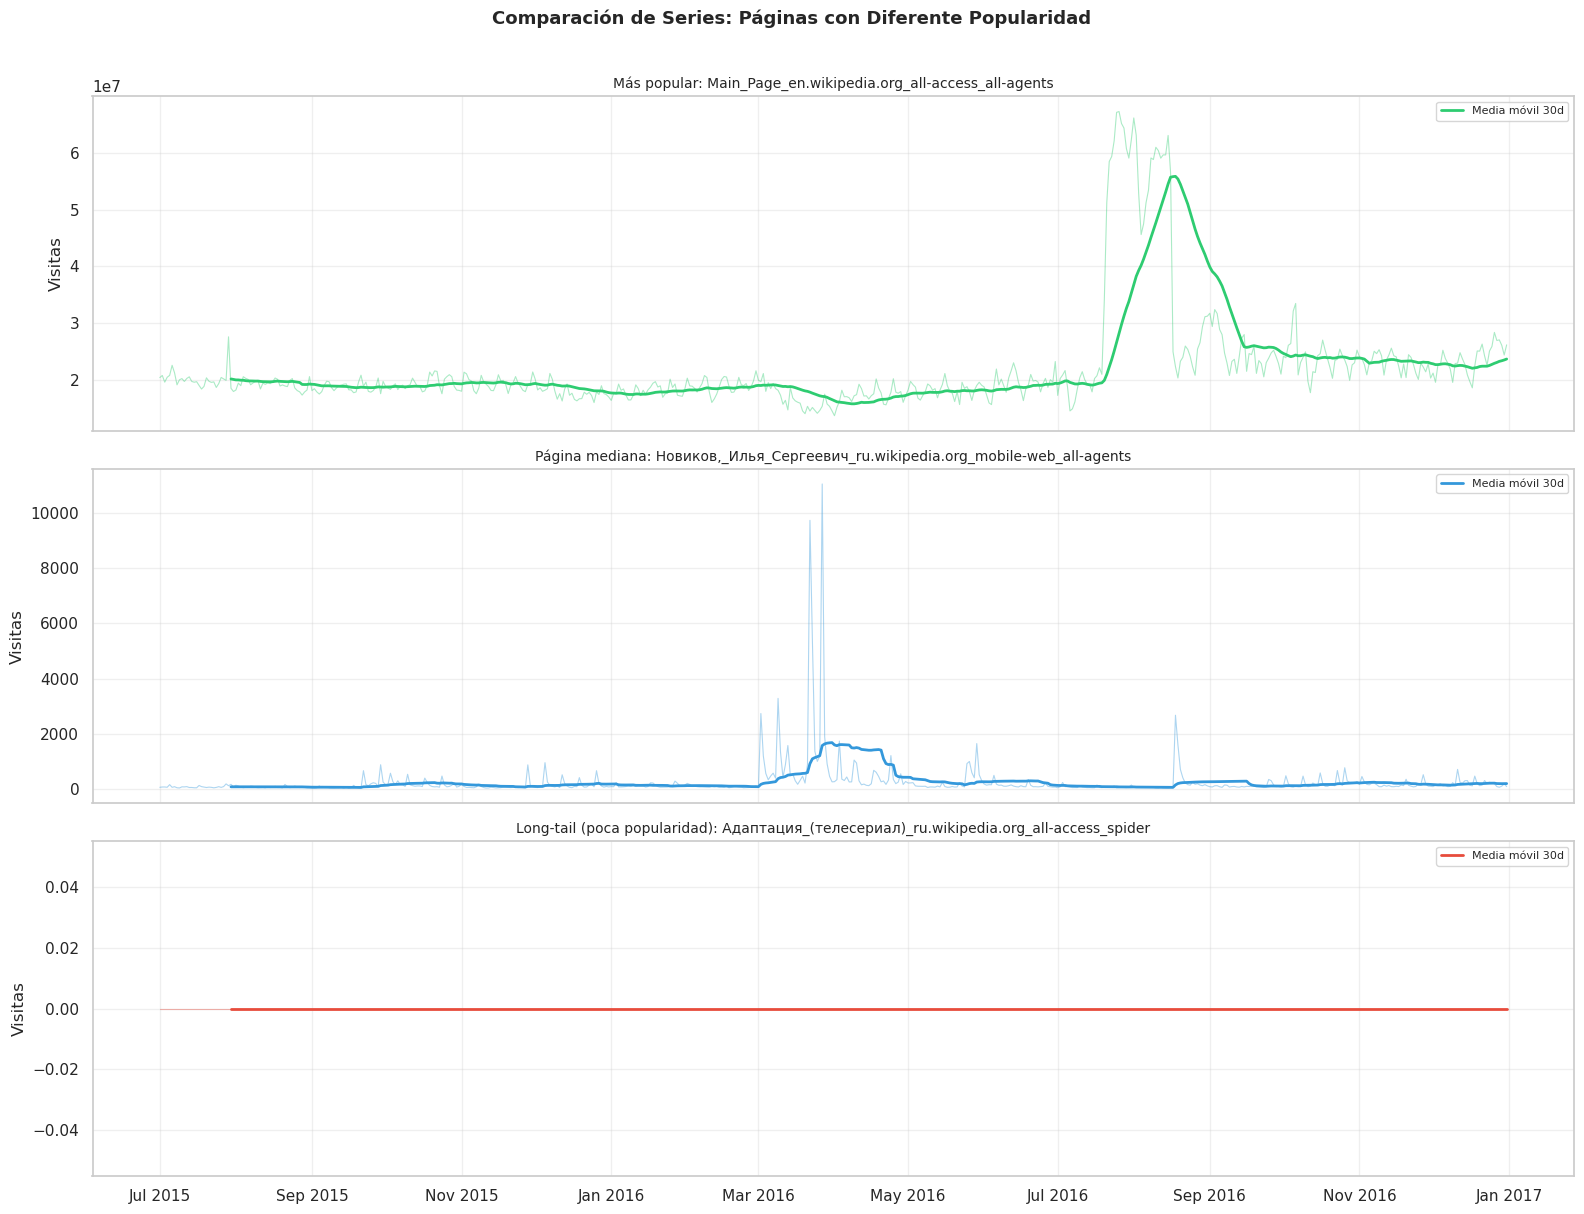

In [25]:
fechas_idx = pd.to_datetime(date_cols)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
colores = ['#2ecc71', '#3498db', '#e74c3c']
labels = ['Más popular', 'Página mediana', 'Long-tail (poca popularidad)']

# Índices: más popular, mediana y percentil 25
indices_muestra = [
    df_sorted.index[0],
    df_sorted.index[len(df_sorted)//2],
    df_sorted.index[-100]
]

for ax, idx, color, label in zip(axes, indices_muestra, colores, labels):
    serie = df_raw.loc[idx, date_cols].fillna(0).astype(float)
    serie.index = fechas_idx
    nombre_pagina = df_raw.loc[idx, 'Page'][:70]
    
    rm30 = serie.rolling(30).mean()
    
    ax.plot(fechas_idx, serie.values, color=color, alpha=0.4, linewidth=0.8)
    ax.plot(fechas_idx, rm30.values, color=color, linewidth=2, label='Media móvil 30d')
    ax.set_title(f'{label}: {nombre_pagina}', fontsize=10)
    ax.set_ylabel('Visitas')
    ax.legend(loc='upper right', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('Comparación de Series: Páginas con Diferente Popularidad', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

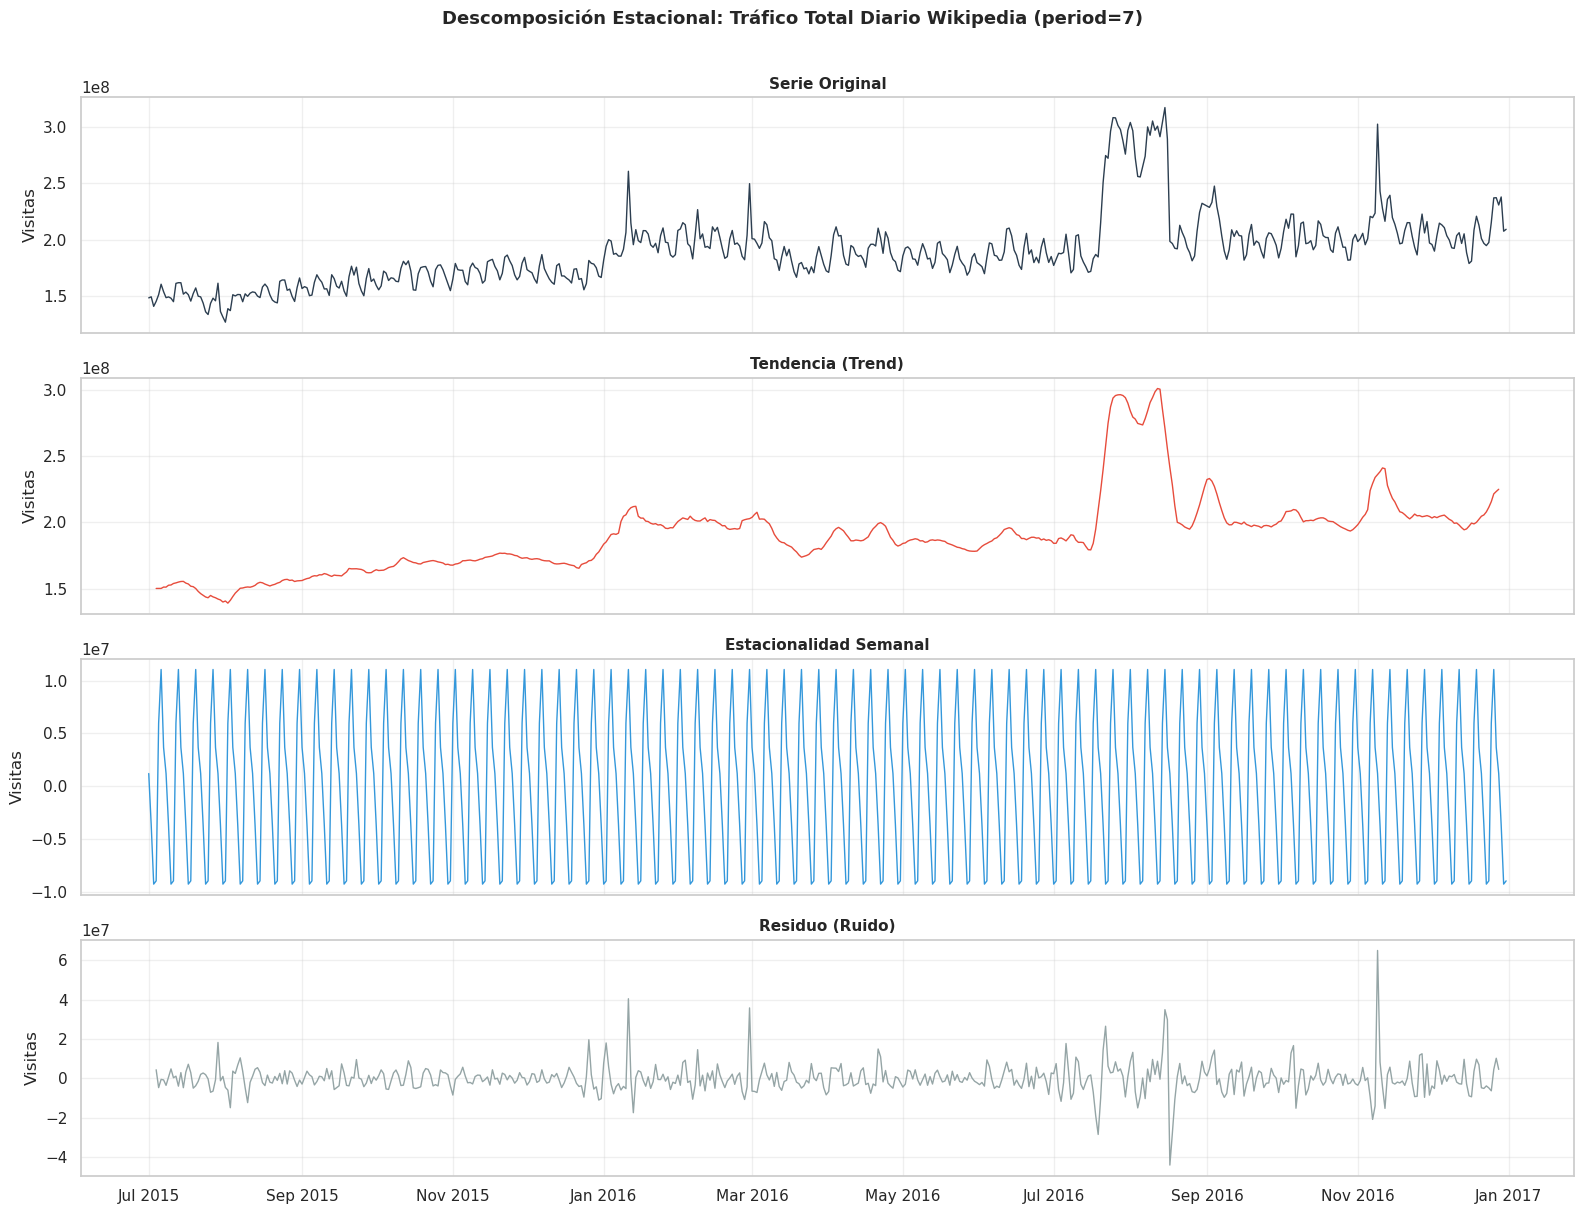

In [12]:
# ── DESCOMPOSICIÓN ESTACIONAL DEL TRÁFICO TOTAL ────────────────────────────
# Usamos la serie total diaria con frecuencia semanal (period=7)
ts_total = total_by_day.copy()
ts_total = ts_total.asfreq('D').fillna(method='ffill')

decomp = seasonal_decompose(ts_total, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
componentes = [
    (ts_total, 'Serie Original', '#2c3e50'),
    (decomp.trend, 'Tendencia (Trend)', '#e74c3c'),
    (decomp.seasonal, 'Estacionalidad Semanal', '#3498db'),
    (decomp.resid, 'Residuo (Ruido)', '#95a5a6'),
]

for ax, (data, titulo, color) in zip(axes, componentes):
    ax.plot(data.index, data.values, color=color, linewidth=1)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_ylabel('Visitas')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.suptitle('Descomposición Estacional: Tráfico Total Diario Wikipedia (period=7)', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()